# Fitting MOSK GPs using Stan

This notebook demonstrates using Stan in python for fitting MOSK GPs.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import nutpie
import arviz as az

os.environ["TBB_CXX_TYPE"] = "clang"  # or 'gcc'

az.style.use("arviz-vibrant")

In [2]:
filename_stub = "D2-Q1-seed2727-n100-mcar0.2-sigma0.1"
#filename_stub = "D2-Q1-seed6893-n200-mnar0.3-sigma0.1"

D = 2
Q = 1

input_df = pd.read_csv(f'data/{filename_stub}-sim.csv')
input_df.head()

,t,f,y,y_se,d
0,0.000000,-0.643858,-0.528319,0.1,1
1,0.010101,-0.742705,-0.813978,0.1,1
2,0.020202,-0.807881,-0.641318,0.1,1
3,0.030303,-0.837087,-0.963527,0.1,1
4,0.050505,-0.785713,-0.790074,0.1,1


In [3]:
input_params = pd.read_table(f'data/{filename_stub}-param.tsv')
input_params

,seed,w,Sigma,mu,theta,phi
0,2727,1.01,0.35,3.61,-0.17,0
1,2727,0.96,0.27,4.70,0.08,0


In [4]:
ns = input_df['d'].value_counts().to_numpy()
ns

array([83, 68])

In [6]:
data = {
    "N": input_df.shape[0],
    "ns": ns,
    "d": input_df['d'],
    "x": input_df['t'],
    "y": input_df['y'],
    "y_se": input_df['y_se']
}

In [7]:
compiled_model = nutpie.compile_stan_model(filename='stan/moskgp-D2.stan').with_data(**data)

In [ ]:
trace = nutpie.sample(
    compiled_model=compiled_model, 
    draws=1000,
    tune=1000,
    chains=6,
    cores=6, 
    progress_rate=2000
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,232,0.26,9
,1500,176,0.28,15
,1500,289,0.09,23
,1500,0,0.49,7
,1500,152,0.20,31
,1500,863,0.05,30


In [62]:
trace

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:      (chain: 6, draw: 1000, w_dim_0: 2, Sigma_dim_0: 2,
│                         mu_dim_0: 2, theta_dim_0: 2, phi_dim_0: 2)
│       Coordinates:
│         * chain        (chain) int64 48B 0 1 2 3 4 5
│         * draw         (draw) int64 8kB 0 1 2 3 4 5 6 ... 993 994 995 996 997 998 999
│         * w_dim_0      (w_dim_0) int64 16B 0 1
│         * Sigma_dim_0  (Sigma_dim_0) int64 16B 0 1
│         * mu_dim_0     (mu_dim_0) int64 16B 0 1
│         * theta_dim_0  (theta_dim_0) int64 16B 0 1
│         * phi_dim_0    (phi_dim_0) int64 16B 0 1
│       Data variables:
│           w            (chain, draw, w_dim_0) float64 96kB 4.575 2.332 ... 4.07 1.225
│           Sigma        (chain, draw, Sigma_dim_0) float64 96kB 6.3 0.8226 ... 0.3796
│           mu           (chain, draw, mu_dim_0) float64 96kB 5.972 5.091 ... 4.857
│           theta        (chain, draw, theta_dim_0) float64 96kB -1.267 ... -0.1143
│           phi          (chain, draw, phi_dim_0) float64 96kB -1.085 ... -0.06948
│           deltaTheta   (chain, draw) float64 48kB 3.893 3.566 3.703 ... 0.6047 0.6047
│       Attributes:
│           created_at:                 2026-09-07T16:35:03.975168+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /sample_stats
│       Dimensions:                   (chain: 6, draw: 1000)
│       Coordinates:
│         * chain                     (chain) int64 48B 0 1 2 3 4 5
│         * draw                      (draw) int64 8kB 0 1 2 3 4 ... 995 996 997 998 999
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 48kB 4 4 3 3 4 ... 5 5 4 5 4
│           maxdepth_reached          (chain, draw) bool 6kB False False ... False False
│           step_size                 (chain, draw) float64 48kB 0.2532 ... 0.04663
│           transformation_update_id  (chain, draw) int64 48kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 48kB 0.2614 ... 0.04812
│           mean_tree_accept          (chain, draw) float64 48kB 0.5941 ... 0.9211
│           ...                        ...
│           fisher_distance           (chain, draw) float64 48kB 21.78 12.56 ... 21.21
│           transformation_index      (chain, draw) int64 48kB 423 423 423 ... 422 422
│           diverging                 (chain, draw) bool 6kB False False ... True True
│           divergence_draw           (chain, draw) uint64 48kB 0 0 503 ... 0 1499 1500
│           divergence_message        (chain, draw) object 48kB None ... "Error durin...
│           divergence_energy_error   (chain, draw) float64 48kB nan nan nan ... nan nan
│       Attributes:
│           created_at:                  2026-09-07T16:35:03.979047+00:00
│           creation_library:            ArviZ
│           creation_library_version:    1.3.0
│           creation_library_language:   Python
│           sample_dims:                 ['chain', 'draw']
│           inference_library:           nutpie
│           inference_library_version:   0.16.11
│           inference_library_settings:  {"sampler": "nuts", "adaptation": "diag", "s...
├── Group: /warmup_posterior
│       Dimensions:      (chain: 6, draw: 500, w_dim_0: 2, Sigma_dim_0: 2, mu_dim_0: 2,
│                         theta_dim_0: 2, phi_dim_0: 2)
│       Coordinates:
│         * chain        (chain) int64 48B 0 1 2 3 4 5
│         * draw         (draw) int64 4kB 0 1 2 3 4 5 6 ... 493 494 495 496 497 498 499
│         * w_dim_0      (w_dim_0) int64 16B 0 1
│         * Sigma_dim_0  (Sigma_dim_0) int64 16B 0 1
│         * mu_dim_0     (mu_dim_0) int64 16B 0 1
│         * theta_dim_0  (theta_dim_0) int64 16B 0 1
│         * phi_dim_0    (phi_dim_0) int64 16B 0 1
│       Data variables:
│           w            (chain, draw, w_dim_0) float64 48kB 0.6759 0.4737 ..

In [63]:
trace.sample_stats.diverging.sum()

<xarray.DataArray 'diverging' ()> Size: 8B
array(1712)

In [64]:
az.ess(trace)

<xarray.DataTree 'posterior'>
Group: /posterior
    Dimensions:      (w_dim_0: 2, Sigma_dim_0: 2, mu_dim_0: 2, theta_dim_0: 2,
                      phi_dim_0: 2)
    Coordinates:
      * w_dim_0      (w_dim_0) int64 16B 0 1
      * Sigma_dim_0  (Sigma_dim_0) int64 16B 0 1
      * mu_dim_0     (mu_dim_0) int64 16B 0 1
      * theta_dim_0  (theta_dim_0) int64 16B 0 1
      * phi_dim_0    (phi_dim_0) int64 16B 0 1
    Data variables:
        w            (w_dim_0) float64 16B 44.84 11.38
        Sigma        (Sigma_dim_0) float64 16B 714.7 8.827
        mu           (mu_dim_0) float64 16B 13.15 11.47
        theta        (theta_dim_0) float64 16B 18.78 31.83
        phi          (phi_dim_0) float64 16B 267.6 168.6
        deltaTheta   float64 8B 12.09

In [65]:
az.rhat(trace)

<xarray.DataTree 'posterior'>
Group: /posterior
    Dimensions:      (w_dim_0: 2, Sigma_dim_0: 2, mu_dim_0: 2, theta_dim_0: 2,
                      phi_dim_0: 2)
    Coordinates:
      * w_dim_0      (w_dim_0) int64 16B 0 1
      * Sigma_dim_0  (Sigma_dim_0) int64 16B 0 1
      * mu_dim_0     (mu_dim_0) int64 16B 0 1
      * theta_dim_0  (theta_dim_0) int64 16B 0 1
      * phi_dim_0    (phi_dim_0) int64 16B 0 1
    Data variables:
        w            (w_dim_0) float64 16B 1.088 1.486
        Sigma        (Sigma_dim_0) float64 16B 1.043 1.8
        mu           (mu_dim_0) float64 16B 1.379 1.469
        theta        (theta_dim_0) float64 16B 1.229 1.12
        phi          (phi_dim_0) float64 16B 1.023 1.029
        deltaTheta   float64 8B 1.451

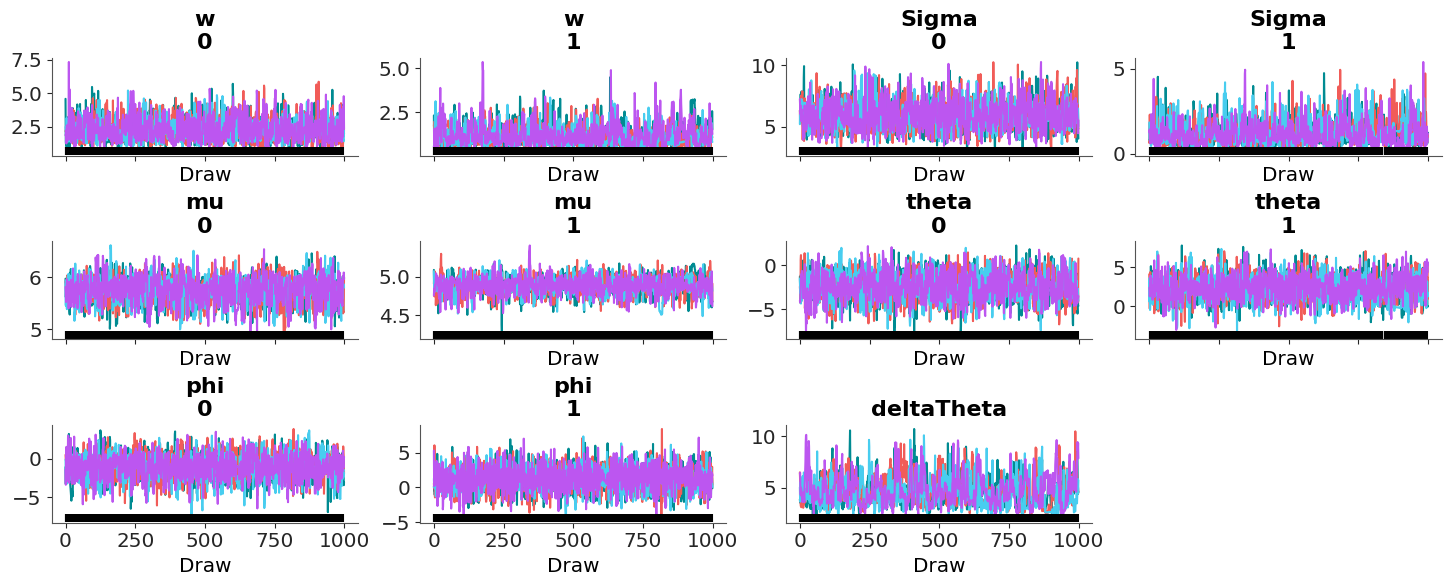

In [75]:
selected_chains = [0,1,2,4]
az.plot_trace(trace.sel(chain = selected_chains));

In [76]:
az.diagnose(trace.sel(chain = selected_chains))

Divergences
849 of 4000 (21.23%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

E-BFMI
E-BFMI satisfactory for all chains.

ESS
Effective sample size satisfactory for all parameters.

R-hat
The following parameters have R-hat values greater than 1.01:
  Sigma, deltaTheta
Such high values indicate incomplete mixing and biased estimation.
You should consider regularizing your model with additional prior information or a more effective parameterization.


True

In [77]:
az.summary(trace.sel(chain = selected_chains))

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
w[0],2.28,0.82,1.2,3.7,1566,1589,1.00,0.021,0.018
w[1],1.18,0.57,0.54,2.2,849,1222,1.01,0.02,0.024
Sigma[0],5.96,1.13,4.2,7.8,1565,1586,1.00,0.028,0.021
Sigma[1],1.21,0.69,0.4,2.5,693,870,1.01,0.025,0.026
mu[0],5.74,0.243,5.3,6.1,1512,1595,1.00,0.0063,0.0047
mu[1],4.882,0.115,4.7,5.1,1279,1529,1.00,0.0033,0.0027
theta[0],-2.35,1.55,-4.9,0.11,1277,1713,1.00,0.043,0.03
theta[1],2.32,1.57,-0.17,4.8,1298,1062,1.00,0.044,0.032
phi[0],-1.07,1.64,-3.8,1.5,1779,1870,1.00,0.039,0.028
phi[1],1.2,1.7,-1.5,4,3156,2349,1.00,0.03,0.022


In [78]:
input_params

,seed,w,Sigma,mu,theta,phi
0,6893,0.96,0.25,5.98,-0.58,0.17
1,6893,1.50,0.69,4.79,0.18,2.01


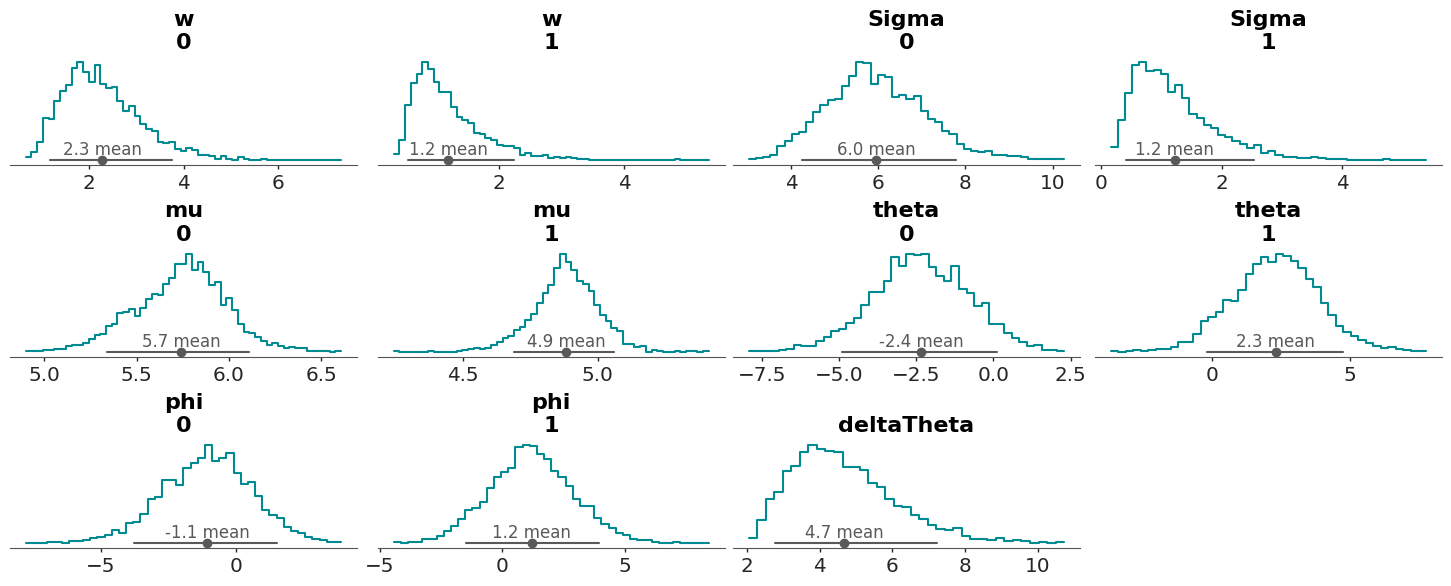

In [80]:
az.plot_dist(trace.sel(chain = selected_chains), kind="hist");

In [81]:
trace.sel(chain = selected_chains).to_netcdf(f'ncdf/{filename_stub}.nc')